### Problem statement: Predict student academic performance using study habits, previous academic history, sleep patterns, and extracurricular participation.

### Important Libraries 

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error

In [2]:
df=pd.read_csv(r'C:\Users\dssas\OneDrive\Desktop\DS\Dataset\Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


### Check the multicolinearity

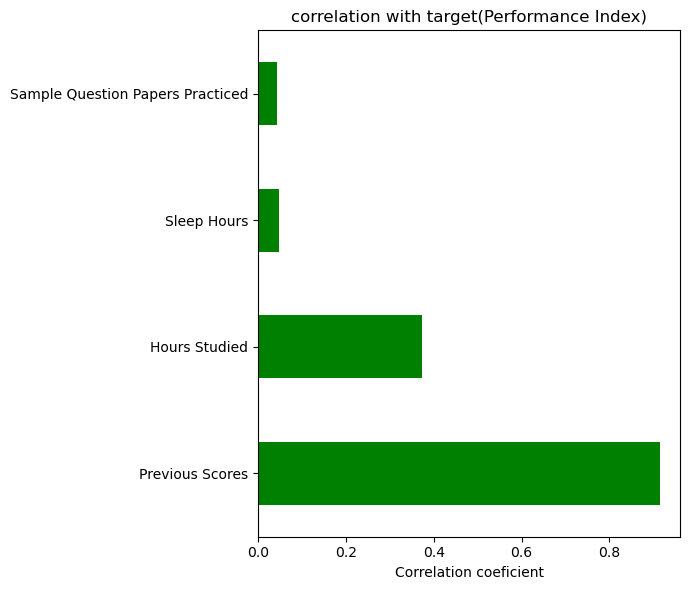

In [3]:
numeric_df=df.select_dtypes(include=[int,float])
target_corr= numeric_df.corr()['Performance Index'].drop('Performance Index').sort_values(key=abs, ascending=False)

plt.figure(figsize=(7,6))
target_corr.plot(kind='barh', color=['green' if v>0 else 'red' for v in target_corr])
plt.title('correlation with target(Performance Index)')
plt.xlabel('Correlation coeficient')
plt.tight_layout()
plt.show()

<Axes: >

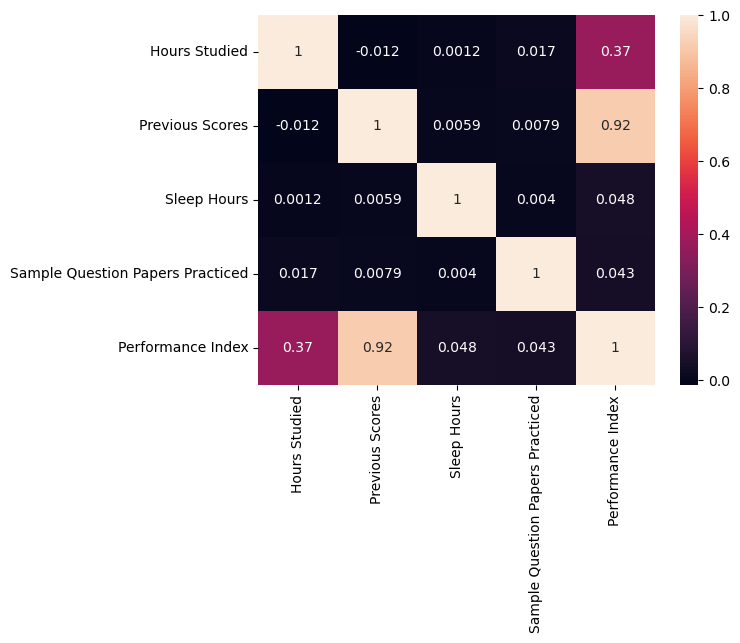

In [4]:
sns.heatmap(df.corr(numeric_only=True), annot= True)

### It shows Performance Index is having correlation only with ours studied and previous score.

### EDA (Data Cleaning)

In [5]:
df.shape

(10000, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [7]:
df.duplicated().sum()

np.int64(127)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(9873, 6)

In [10]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

### Check Outliers

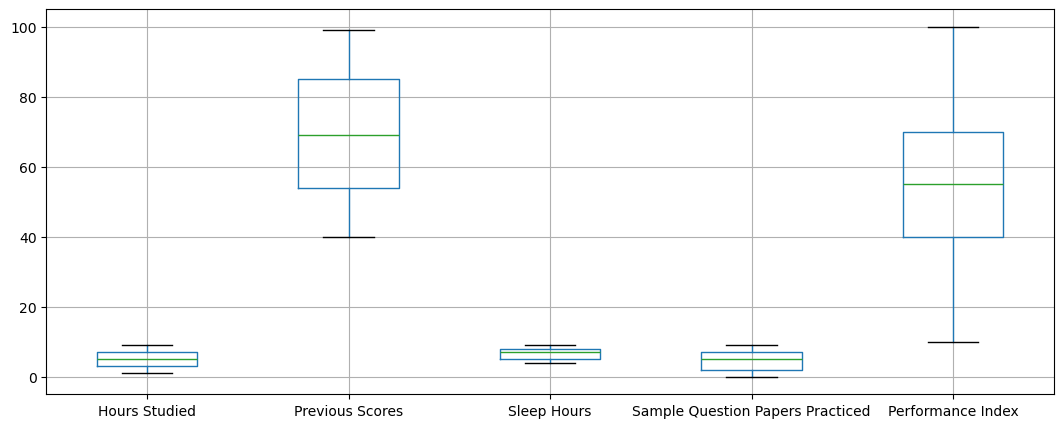

In [11]:
plt.figure(figsize=(13,5))
df.boxplot()
plt.show()

### Encoding

### Ordinal Encoding Extracurricular Activities column

In [12]:
df['Extracurricular Activities']= df['Extracurricular Activities'].map({'Yes':1, 'No':0})

In [13]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


### split data into train and test

In [16]:
x=df.iloc[:,:-1]
y=df['Performance Index']

In [17]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=42)

In [18]:
lr=LinearRegression()
lr.fit(xtrain,ytrain)


LinearRegression()

#### coef_ gives the coefficient (slope) learned by the Linear Regression model after training.
#### It tells: “How much does y change when x increases by 1 unit?”

In [19]:
lr.coef_

array([2.85364318, 1.01801988, 0.57797717, 0.4715297 , 0.19003358])

#### intercept_ gives the intercept (constant value) of the Linear Regression model.
#### It is the value of y when x = 0.

In [20]:
lr.intercept_

np.float64(-33.976894833518216)

### Get the Prediction

In [21]:
ypred=lr.predict(xtest)
ypred

array([46.47674371, 80.27452611, 61.05760438, ..., 58.56041781,
       38.62446369, 33.82296889])

### Evaluate the model

In [23]:
mse=mean_squared_error(ytest,ypred)
mae=mean_absolute_error(ytest,ypred)
r2_score(ytest,ypred)

0.9883149212472457

In [24]:
print(f'mse= {mse}')
print(f'mae={mae}')
print(f'r2_score= {r2_score(ytest,ypred)}')

mse= 4.317099922622562
mae=1.6486334804527565
r2_score= 0.9883149212472457


In [26]:
print(f'Training Accurary: {lr.score(xtrain,ytrain)}')
print(f'Testing Accuray: {lr.score(xtest,ytest)}')

Training Accurary: 0.9887979467634684
Testing Accuray: 0.9883149212472457


### Conclusion

### The model achieved an R² score of 98.83%, indicating an excellent fit and a strong relationship between the input features and student performance.The low MAE (1.65) and MSE (4.32) demonstrate that the model makes highly accurate predictions. Overall, the model is reliable for predicting student performance and can help educational institutions identify factors that influence academic success and support data-driven decision-making.